In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 데이터 불러오기
df = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/최종_ML용_데이터.csv', encoding='utf-8-sig')

print(f'shape: {df.shape}')
print(df.head(3))

shape: (1037, 25)
    구명    연도     업종       평균_당월매출     연령대_20_매출     연령대_30_매출     연령대_40_매출  \
0  강남구  2019  분식전문점  6.533841e+08  1.279386e+08  1.448395e+08  1.427872e+08   
1  강남구  2019  양식음식점  1.366631e+09  2.688714e+08  3.211270e+08  2.250849e+08   
2  강남구  2019  일식음식점  9.675838e+08  1.774149e+08  2.076301e+08  1.397524e+08   

      연령대_50_매출    폐업률         총_유동인구  ...          평균_하차    총_직장인구  직장인구_20대  \
0  8.195965e+07  63.75  928198.929612  ...  630089.903646  937043.0  186311.0   
1  1.425676e+08  62.33  928198.929612  ...  630089.903646  937043.0  186311.0   
2  8.413404e+07  52.27  928198.929612  ...  630089.903646  937043.0  186311.0   

   직장인구_30대  직장인구_40대  직장인구_50대  출근시간_유동인구_06_11  점심시간_유동인구_11_14  \
0  286727.0  238932.0  155251.0    186583.436893    149304.470874   
1  286727.0  238932.0  155251.0    186583.436893    149304.470874   
2  286727.0  238932.0  155251.0    186583.436893    149304.470874   

   저녁시간_유동인구_17_21  주말_매출_비율  
0    172608.453883    0.2176  
1

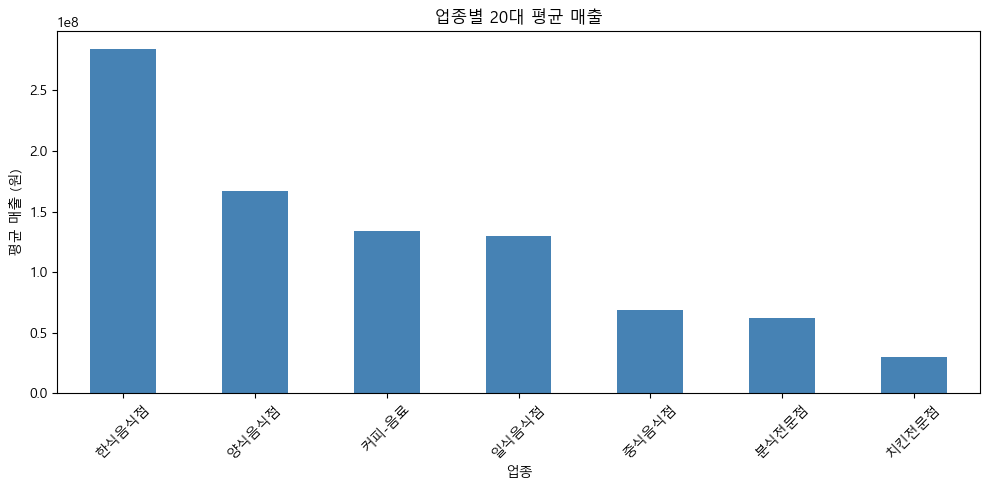

업종
한식음식점    2.845733e+08
양식음식점    1.667194e+08
커피-음료    1.336617e+08
일식음식점    1.296080e+08
중식음식점    6.908866e+07
분식전문점    6.231279e+07
치킨전문점    3.042815e+07
Name: 연령대_20_매출, dtype: float64


In [3]:
# 업종별 20대 평균 매출
df_20 = df.groupby('업종')['연령대_20_매출'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
df_20.plot(kind='bar', color='steelblue')
plt.title('업종별 20대 평균 매출')
plt.xlabel('업종')
plt.ylabel('평균 매출 (원)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(df_20)

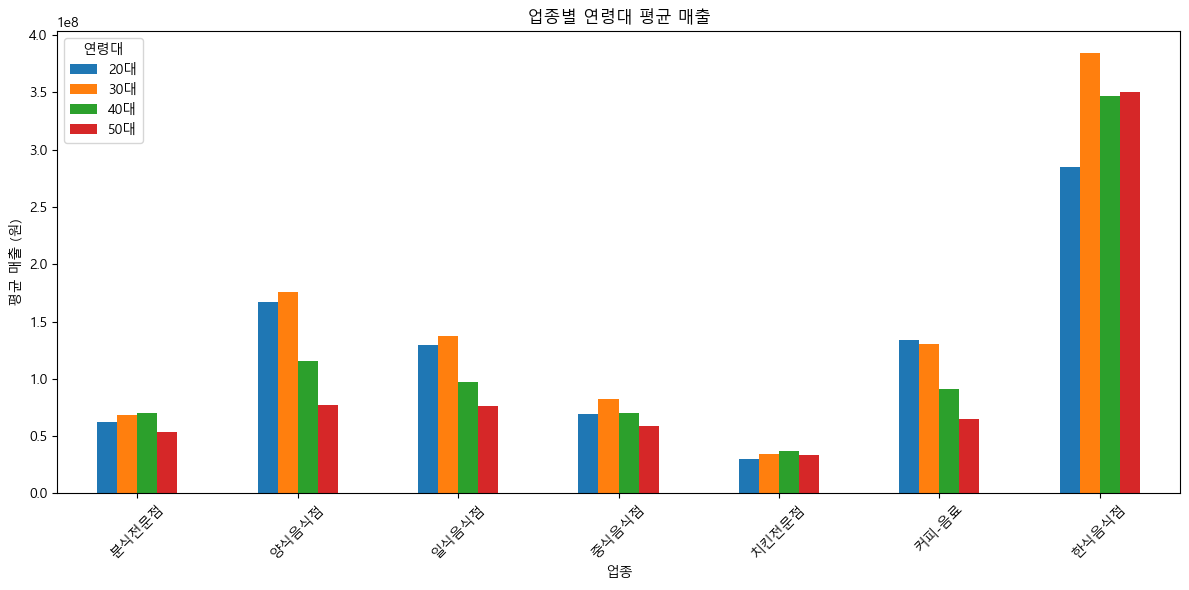

               20대          30대          40대          50대
업종                                                       
분식전문점   62312788.0   68636142.0   70084221.0   53656224.0
양식음식점  166719425.0  175818461.0  115317770.0   77248205.0
일식음식점  129608030.0  137832029.0   97271550.0   76525546.0
중식음식점   69088663.0   82324484.0   69844196.0   59059704.0
치킨전문점   30428146.0   34334517.0   37160998.0   33344165.0
커피-음료  133661675.0  130183849.0   91435366.0   64977904.0
한식음식점  284573277.0  384127443.0  347191957.0  350749193.0


In [4]:
# 업종별 연령대별 평균 매출
age_cols = ['연령대_20_매출', '연령대_30_매출', '연령대_40_매출', '연령대_50_매출']

df_age = df.groupby('업종')[age_cols].mean()
df_age.columns = ['20대', '30대', '40대', '50대']

df_age.plot(kind='bar', figsize=(12, 6))
plt.title('업종별 연령대 평균 매출')
plt.xlabel('업종')
plt.ylabel('평균 매출 (원)')
plt.xticks(rotation=45)
plt.legend(title='연령대')
plt.tight_layout()
plt.show()

print(df_age.round(0))

#### 한식의 압도적인 이유
#### 가장 보편적인 외식업종
#### 매장수 자체가 가장 많아서 매출 합계 도 높음
#### 모든 연령대에서 고르게 소비






#### 양식/일식 → 20대, 30대 비중 높음 젊은 층이 선호

#### 커피-음료  → 20대 매출이 30대보다 높음 카페는 20대가 주도
         


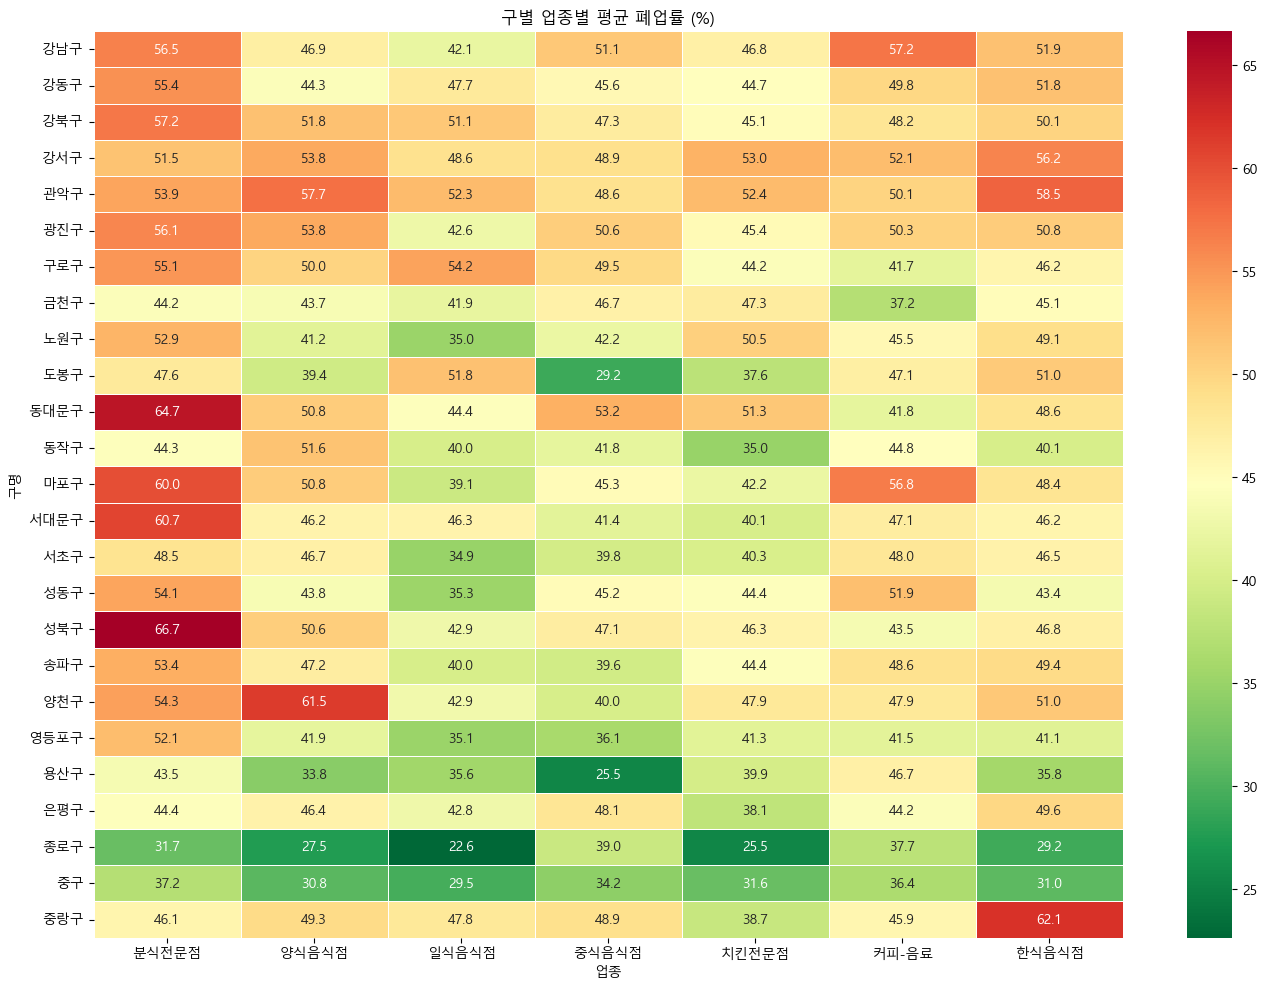

In [5]:
# 구별 업종별 평균 폐업률
df_pivot = df.groupby(['구명', '업종'])['폐업률'].mean().unstack()

plt.figure(figsize=(14, 10))
sns.heatmap(df_pivot, 
            annot=True, 
            fmt='.1f', 
            cmap='RdYlGn_r',
            linewidths=0.5)
plt.title('구별 업종별 평균 폐업률 (%)')
plt.xlabel('업종')
plt.ylabel('구명')
plt.tight_layout()
plt.show()


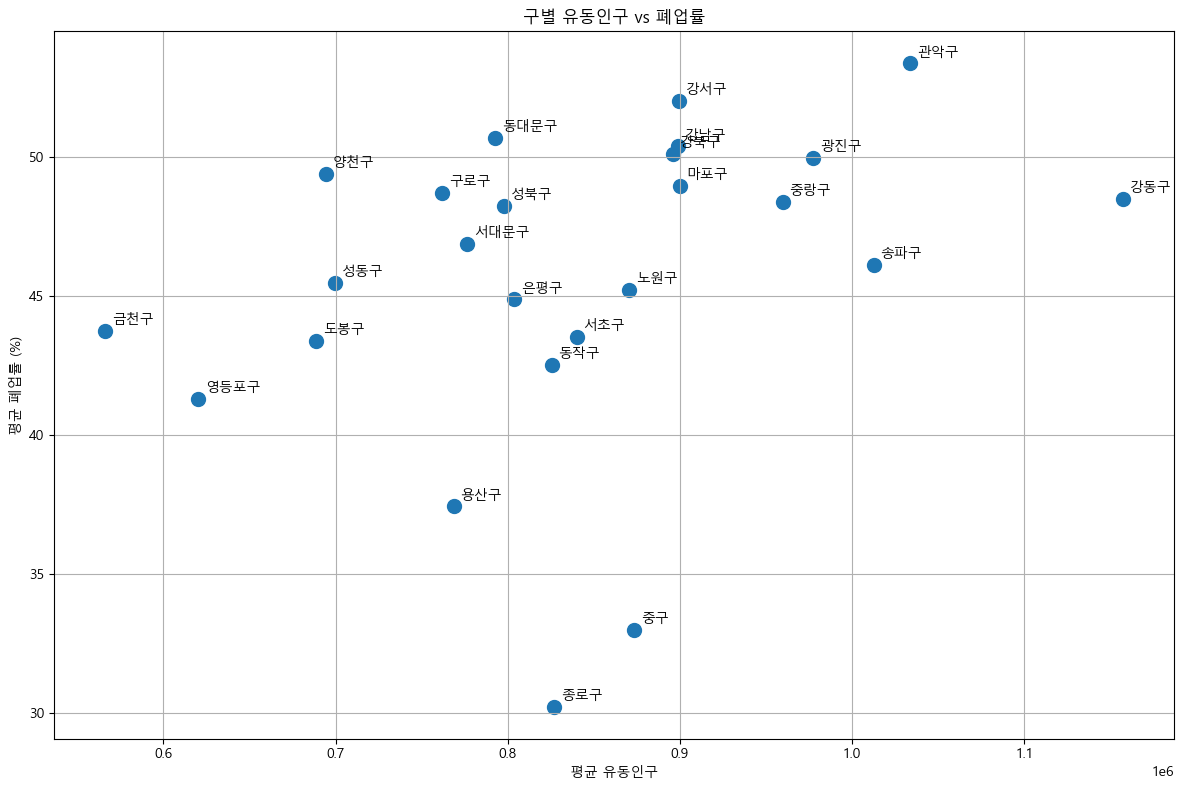

In [6]:
# 구별 평균 유동인구 + 평균 폐업률
df_scatter = df.groupby('구명').agg(
    평균_유동인구=('총_유동인구', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_scatter['평균_유동인구'], 
            df_scatter['평균_폐업률'], 
            s=100)

# 구 이름 표시
for idx, row in df_scatter.iterrows():
    plt.annotate(row['구명'], 
                 (row['평균_유동인구'], row['평균_폐업률']),
                 textcoords='offset points',
                 xytext=(5, 5))

plt.title('구별 유동인구 vs 폐업률')
plt.xlabel('평균 유동인구')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

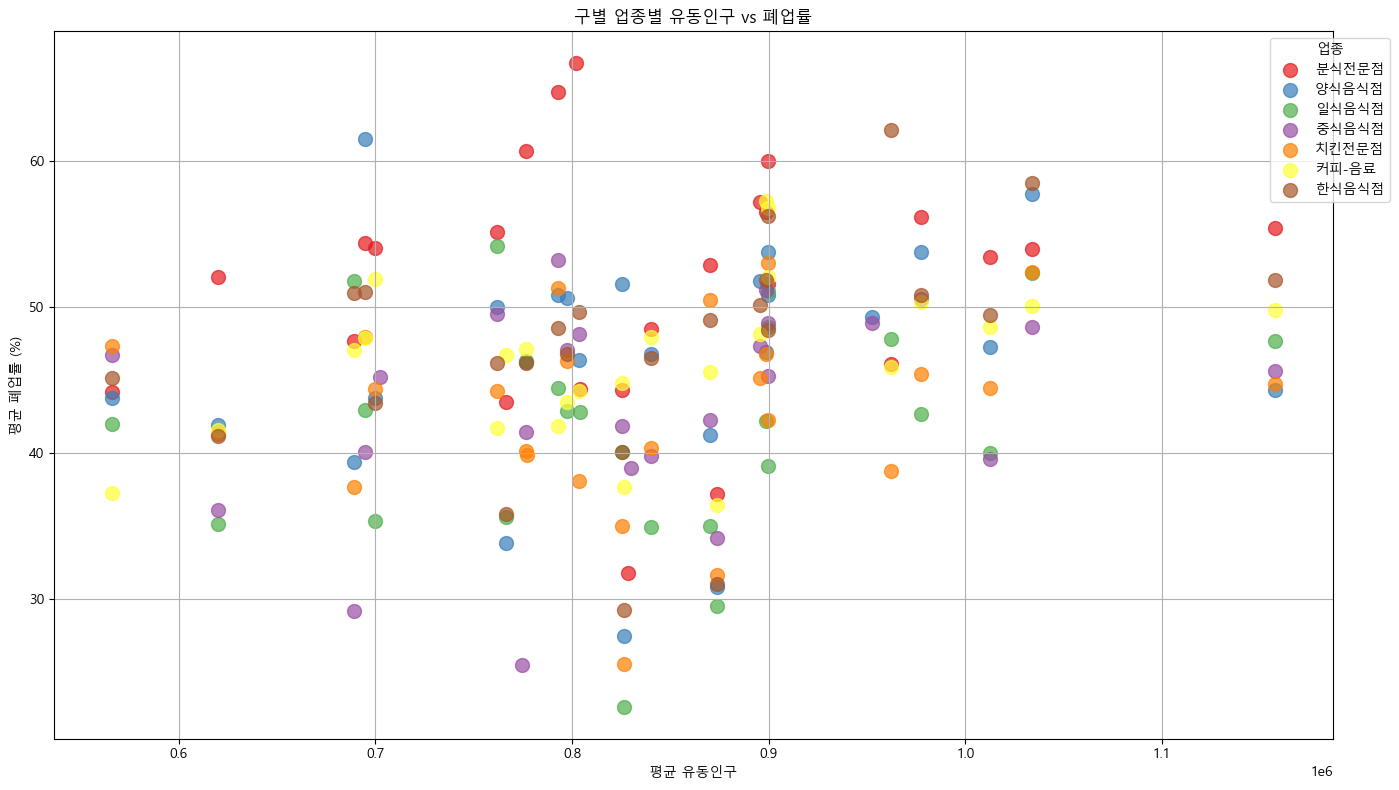

In [7]:
# 구별 업종별 유동인구 + 폐업률
df_bubble = df.groupby(['구명', '업종']).agg(
    평균_유동인구=('총_유동인구', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

# 업종별 색상 지정
업종목록 = df_bubble['업종'].unique()
colors = plt.cm.Set1.colors
색상맵 = {업종: colors[i] for i, 업종 in enumerate(업종목록)}

plt.figure(figsize=(14, 8))

for 업종 in 업종목록:
    temp = df_bubble[df_bubble['업종'] == 업종]
    plt.scatter(temp['평균_유동인구'],
                temp['평균_폐업률'],
                s=100,
                label=업종,
                color=색상맵[업종],
                alpha=0.7)

plt.title('구별 업종별 유동인구 vs 폐업률')
plt.xlabel('평균 유동인구')
plt.ylabel('평균 폐업률 (%)')
plt.legend(title='업종', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.tight_layout()
plt.show()

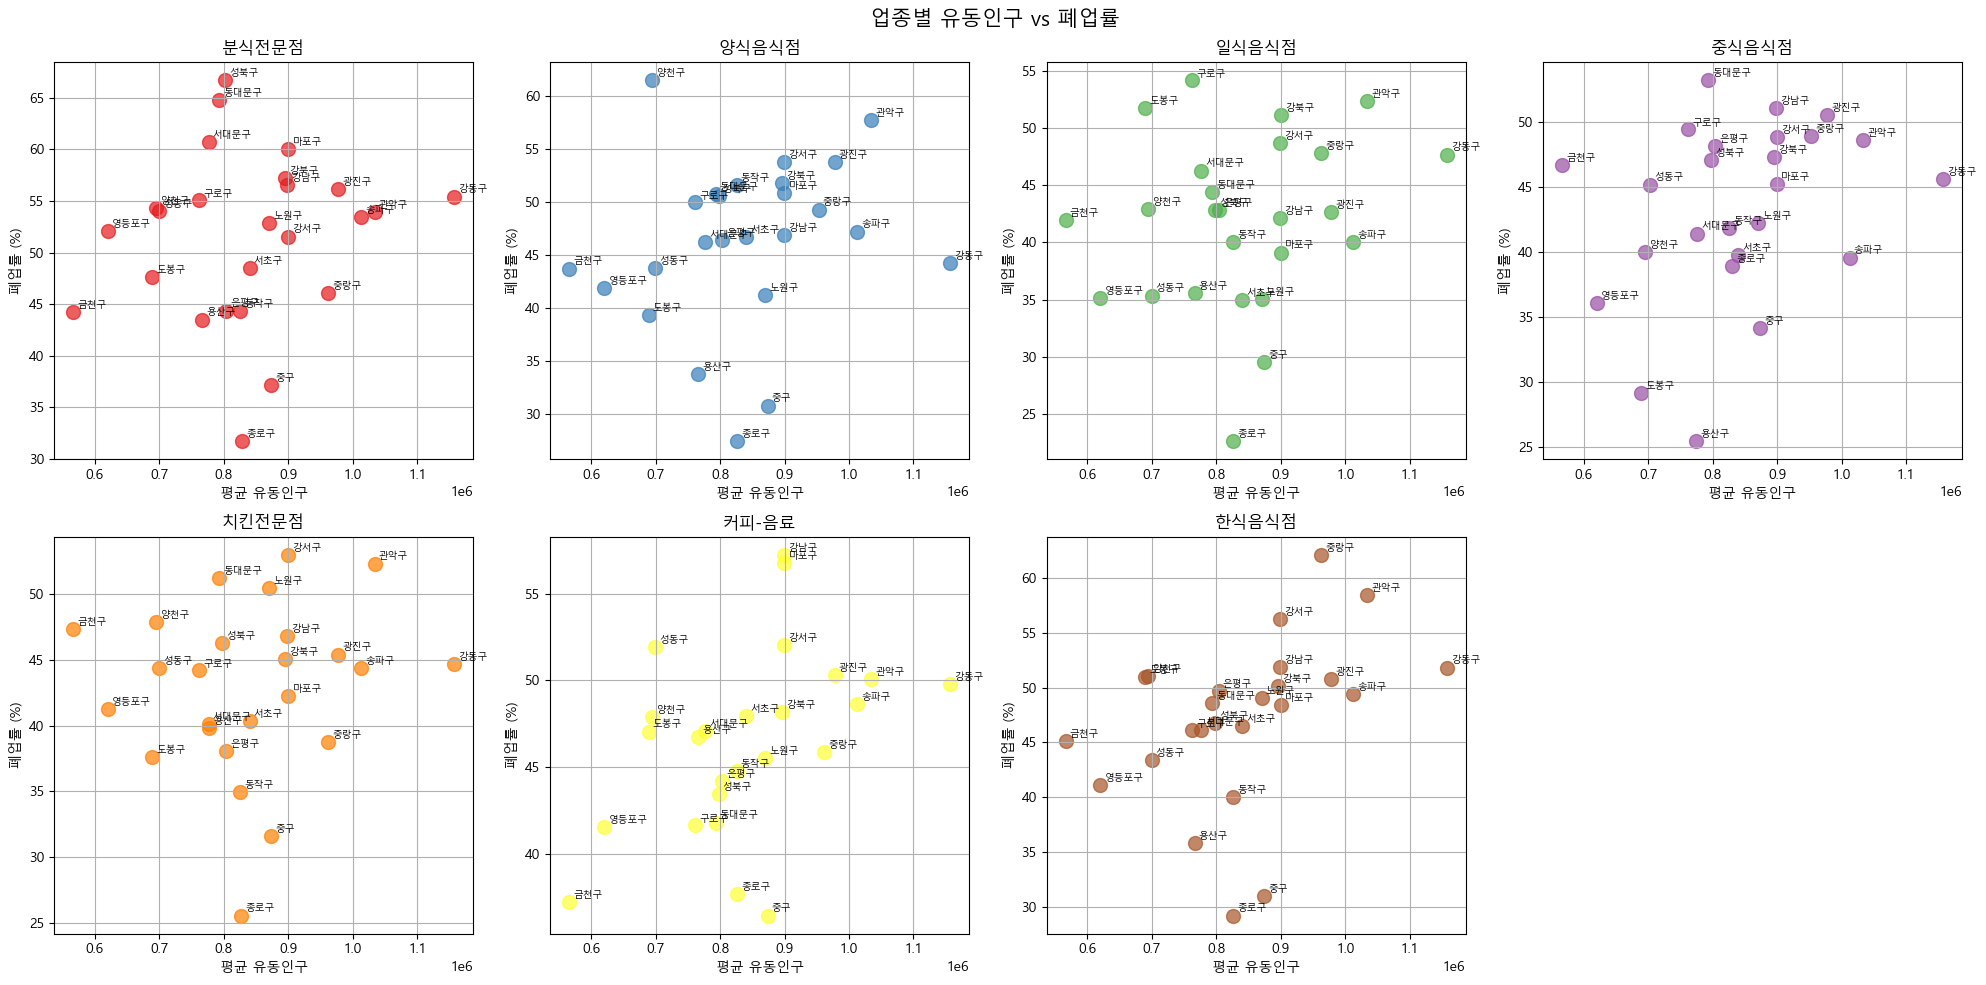

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, 업종 in enumerate(업종목록):
    temp = df_bubble[df_bubble['업종'] == 업종]
    
    axes[i].scatter(temp['평균_유동인구'],
                    temp['평균_폐업률'],
                    s=100,
                    color=colors[i],
                    alpha=0.7)
    
    # 구 이름 표시
    for _, row in temp.iterrows():
        axes[i].annotate(row['구명'],
                        (row['평균_유동인구'], row['평균_폐업률']),
                        fontsize=7,
                        xytext=(3, 3),
                        textcoords='offset points')
    
    axes[i].set_title(f'{업종}')
    axes[i].set_xlabel('평균 유동인구')
    axes[i].set_ylabel('폐업률 (%)')
    axes[i].grid(True)

# 빈 subplot 제거
axes[-1].set_visible(False)

plt.suptitle('업종별 유동인구 vs 폐업률', fontsize=15)
plt.tight_layout()
plt.show()

In [9]:
# 강남구 vs 강동구 커피-음료 폐업률 직접 비교
check = df[df['업종'] == '커피-음료'][['구명', '연도', '폐업률']]
print(check[check['구명'].isin(['강남구', '강동구'])].sort_values(['구명', '연도']))
print()
print('전체 평균:')
print(check[check['구명'].isin(['강남구', '강동구'])].groupby('구명')['폐업률'].mean())

     구명    연도    폐업률
5   강남구  2019  78.47
12  강남구  2020  64.74
19  강남구  2021  49.50
26  강남구  2022  57.41
33  강남구  2023  50.31
40  강남구  2024  43.03
47  강동구  2019  62.62
54  강동구  2020  59.65
61  강동구  2021  55.30
68  강동구  2022  43.22
75  강동구  2023  51.04
82  강동구  2024  26.83

전체 평균:
구명
강남구    57.243333
강동구    49.776667
Name: 폐업률, dtype: float64


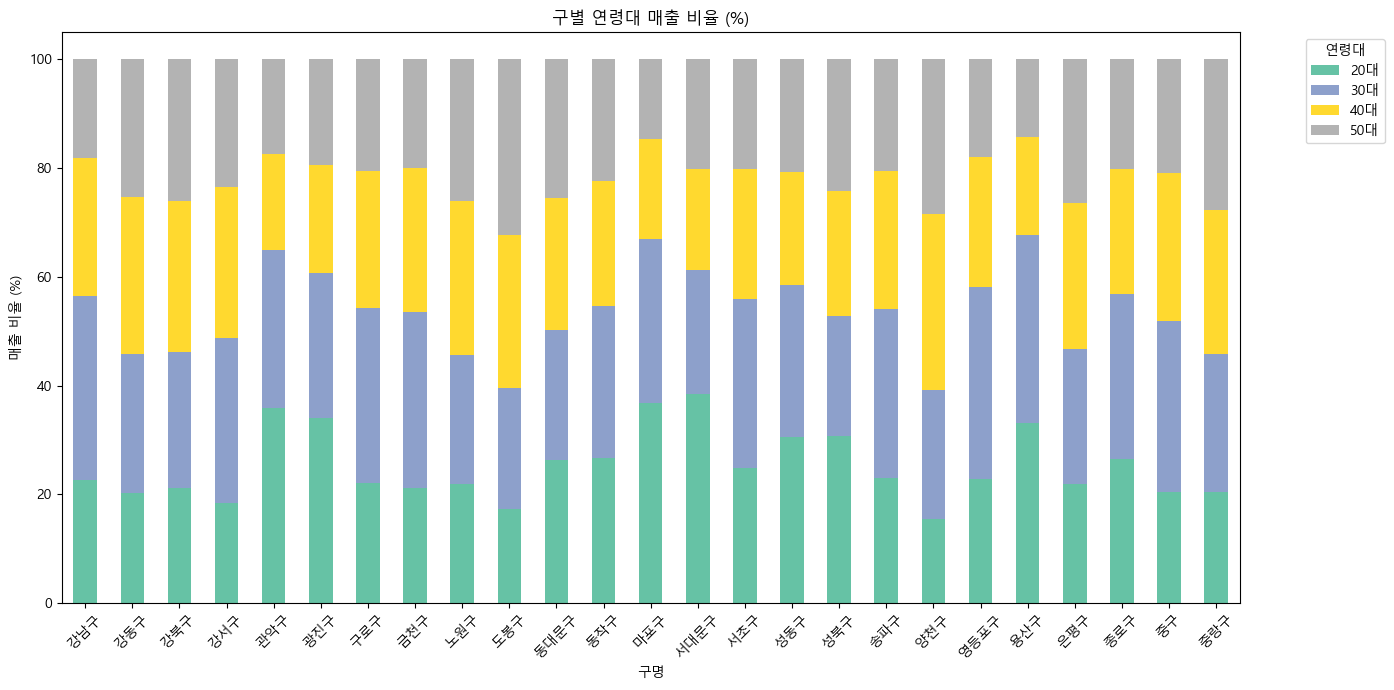

In [10]:
# 구별 연령대별 매출 합산
age_cols = ['연령대_20_매출', '연령대_30_매출', '연령대_40_매출', '연령대_50_매출']

df_age_gu = df.groupby('구명')[age_cols].mean()
df_age_gu.columns = ['20대', '30대', '40대', '50대']

# 비율로 변환
df_age_ratio = df_age_gu.div(df_age_gu.sum(axis=1), axis=0) * 100

df_age_ratio.plot(kind='bar', stacked=True, figsize=(14, 7), colormap='Set2')
plt.title('구별 연령대 매출 비율 (%)')
plt.xlabel('구명')
plt.ylabel('매출 비율 (%)')
plt.xticks(rotation=45)
plt.legend(title='연령대', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [11]:
# 구별 주도 연령대 찾기
df_age_gu = df.groupby('구명')[age_cols].mean()
df_age_gu.columns = ['20대', '30대', '40대', '50대']

# 가장 많이 소비하는 연령대
df_age_gu['주요연령대'] = df_age_gu.idxmax(axis=1)

# 폐업률 붙이기
df_gu_closure = df.groupby('구명')['폐업률'].mean().reset_index()
df_age_gu = df_age_gu.reset_index()
df_age_gu = pd.merge(df_age_gu, df_gu_closure, on='구명')

print(df_age_gu[['구명', '주요연령대', '폐업률']].sort_values('폐업률'))

      구명 주요연령대        폐업률
22   종로구   30대  30.218750
23    중구   30대  32.968571
20   용산구   30대  37.419231
19  영등포구   30대  41.301190
11   동작구   30대  42.507381
9    도봉구   50대  43.370476
14   서초구   30대  43.531190
7    금천구   30대  43.745476
21   은평구   40대  44.868000
8    노원구   40대  45.206190
15   성동구   20대  45.448293
17   송파구   30대  46.097857
13  서대문구   20대  46.854762
16   성북구   20대  48.226000
24   중랑구   50대  48.361000
1    강동구   40대  48.471429
6    구로구   30대  48.689048
12   마포구   20대  48.940714
18   양천구   40대  49.371429
5    광진구   20대  49.946429
2    강북구   40대  50.085610
0    강남구   30대  50.372381
10  동대문구   20대  50.691429
3    강서구   30대  52.017857
4    관악구   20대  53.357381


#### 30대 직장인 중심 상권 → 소비력 높고 안정적 → 폐업률 낮음

#### 20대 중심 상권 → 유행에 민감하고 소비 변동 큼 → 관악구(대학가), 마포구(홍대) 등 → 폐업률 높음

#### 30대 직장인 소비가 주도하는 상권이 폐업률이 낮고, 20대 중심 상권은 유행 변화에 민감해 폐업률이 상대적으로 높다


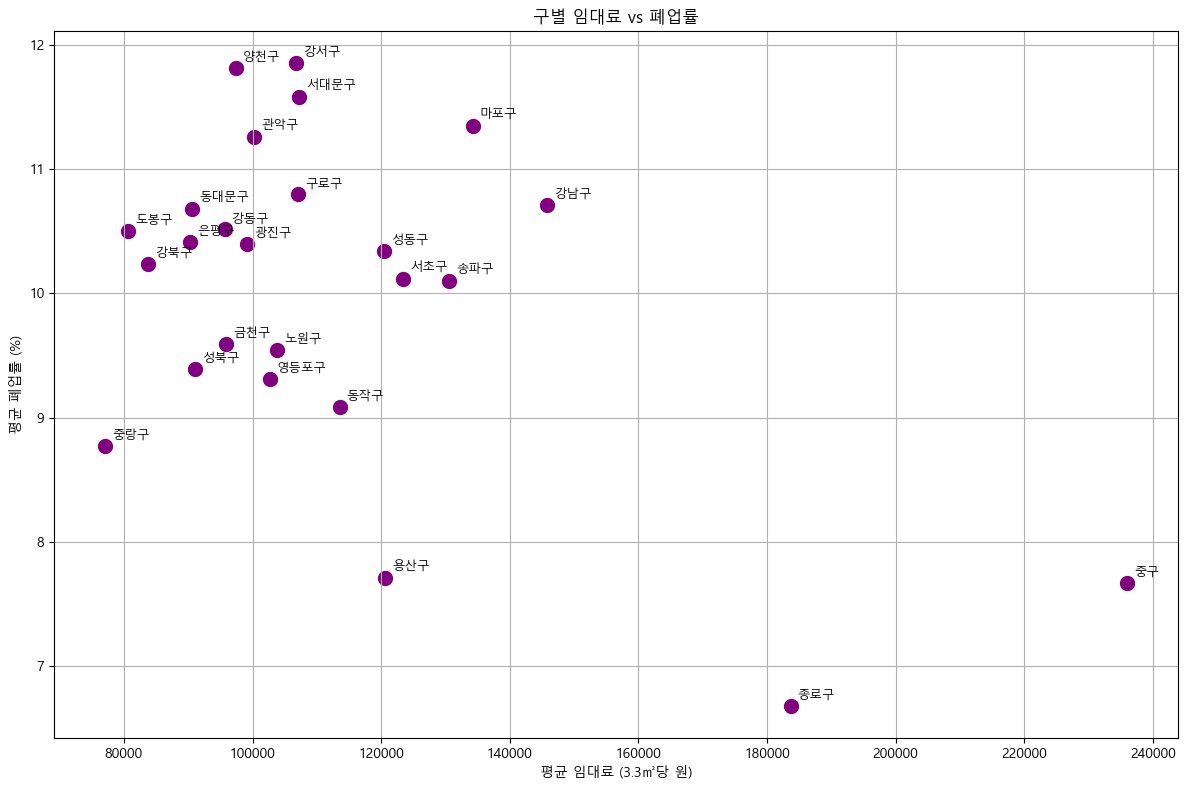

In [13]:
df = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/최종_ML용_데이터_v2.csv',
                 encoding='utf-8-sig')

df_rent_scatter = df.groupby('구명').agg(
    평균_임대료=('임대료', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_rent_scatter['평균_임대료'],
            df_rent_scatter['평균_폐업률'],
            s=100, color='purple')

for _, row in df_rent_scatter.iterrows():
    plt.annotate(row['구명'],
                (row['평균_임대료'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9)

plt.title('구별 임대료 vs 폐업률')
plt.xlabel('평균 임대료 (3.3㎡당 원)')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 

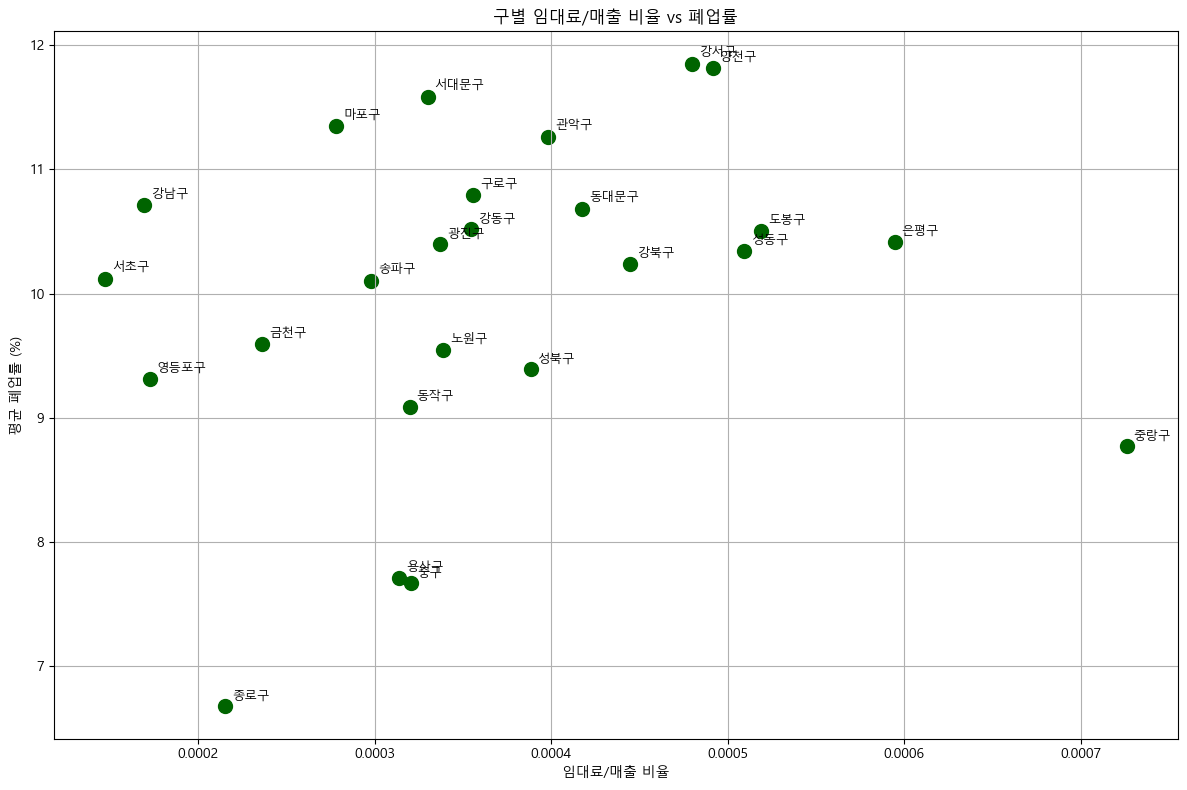

In [16]:
df = pd.read_csv('C:/Users/human/미정프로젝트/새 폴더/최종_ML용_데이터_v2.csv',
                 encoding='utf-8-sig')

df_ratio_scatter = df.groupby('구명').agg(
    평균_임대료매출비율=('임대료_매출_비율', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

plt.figure(figsize=(12, 8))
plt.scatter(df_ratio_scatter['평균_임대료매출비율'],
            df_ratio_scatter['평균_폐업률'],
            s=100, color='darkgreen')

for _, row in df_ratio_scatter.iterrows():
    plt.annotate(row['구명'],
                (row['평균_임대료매출비율'], row['평균_폐업률']),
                textcoords='offset points',
                xytext=(5, 5), fontsize=9)

plt.title('구별 임대료/매출 비율 vs 폐업률')
plt.xlabel('임대료/매출 비율')
plt.ylabel('평균 폐업률 (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

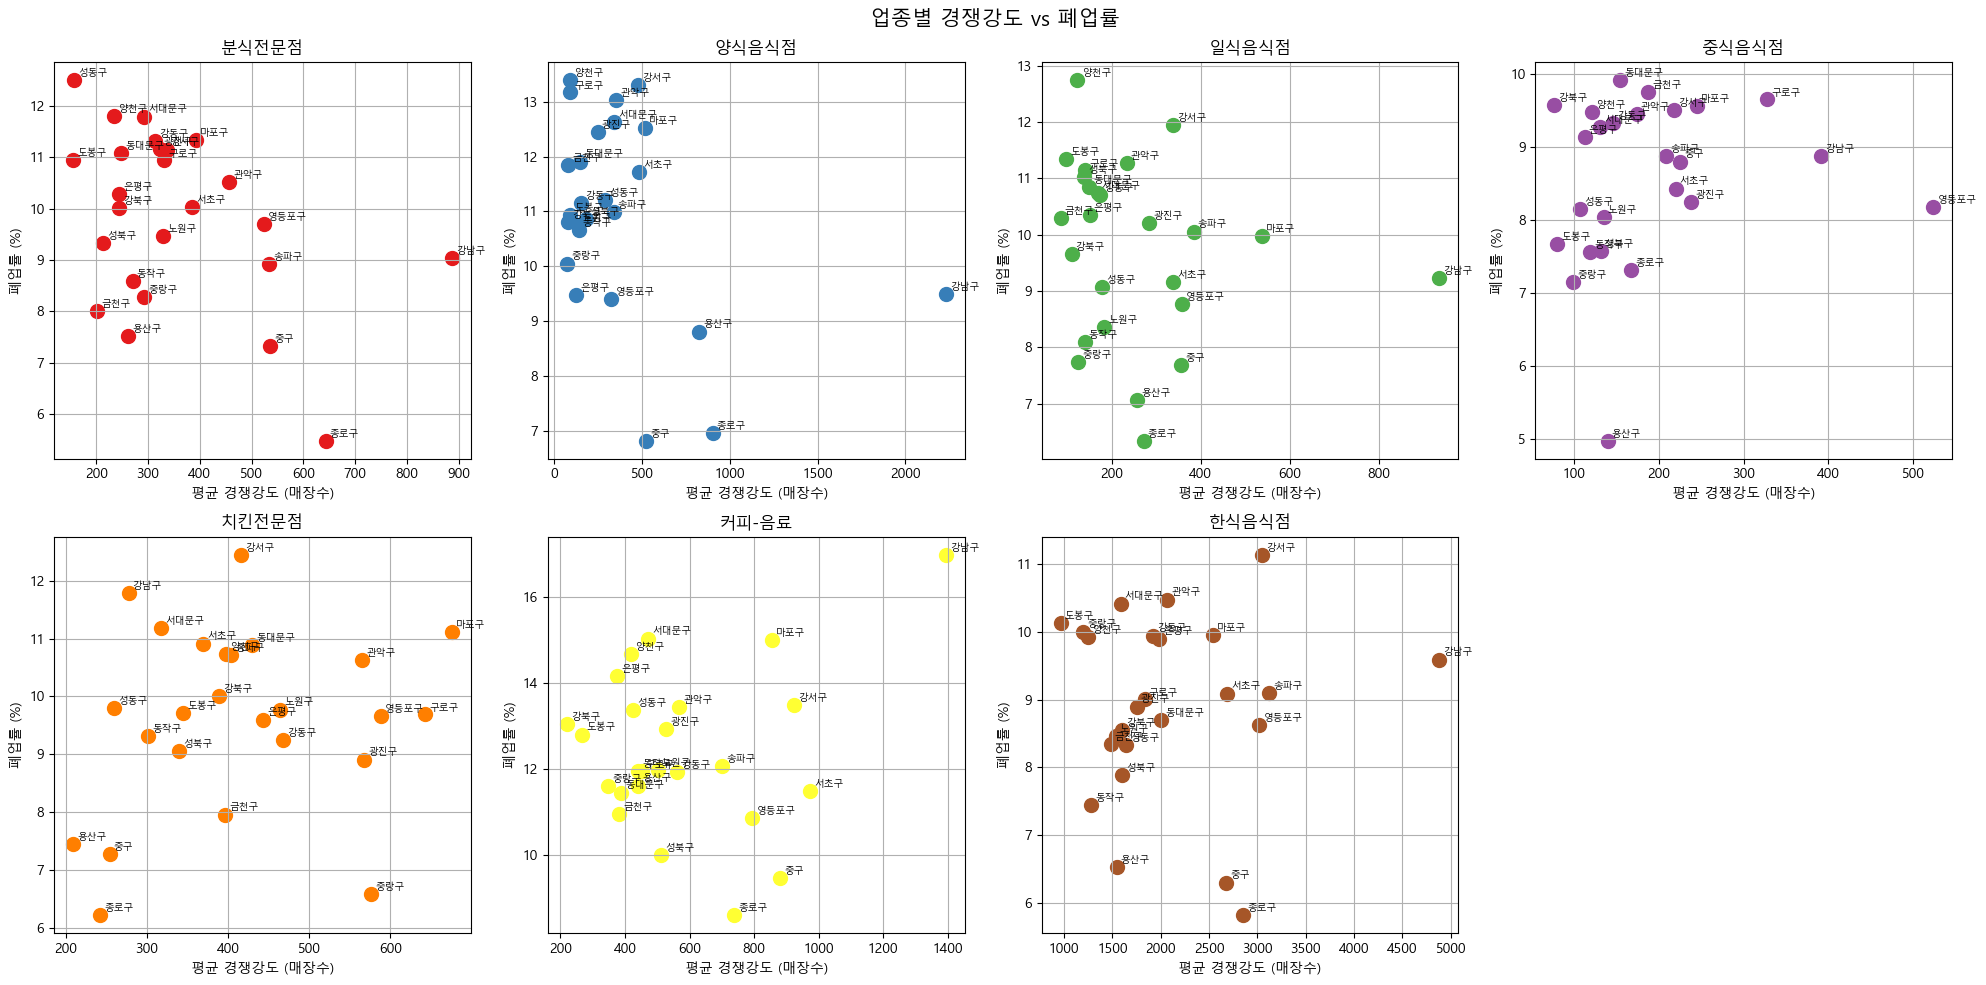

In [18]:
df_comp_scatter = df.groupby(['구명', '업종']).agg(
    평균_경쟁강도=('경쟁강도', 'mean'),
    평균_폐업률=('폐업률', 'mean')
).reset_index()

업종목록 = df_comp_scatter['업종'].unique()
colors = plt.cm.Set1.colors

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, 업종 in enumerate(업종목록):
    temp = df_comp_scatter[df_comp_scatter['업종'] == 업종]
    axes[i].scatter(temp['평균_경쟁강도'],
                    temp['평균_폐업률'],
                    s=100, color=colors[i])
    for _, row in temp.iterrows():
        axes[i].annotate(row['구명'],
                        (row['평균_경쟁강도'], row['평균_폐업률']),
                        fontsize=7, xytext=(3, 3),
                        textcoords='offset points')
    axes[i].set_title(f'{업종}')
    axes[i].set_xlabel('평균 경쟁강도 (매장수)')
    axes[i].set_ylabel('폐업률 (%)')
    axes[i].grid(True)

axes[-1].set_visible(False)
plt.suptitle('업종별 경쟁강도 vs 폐업률', fontsize=15)
plt.tight_layout()
plt.show()

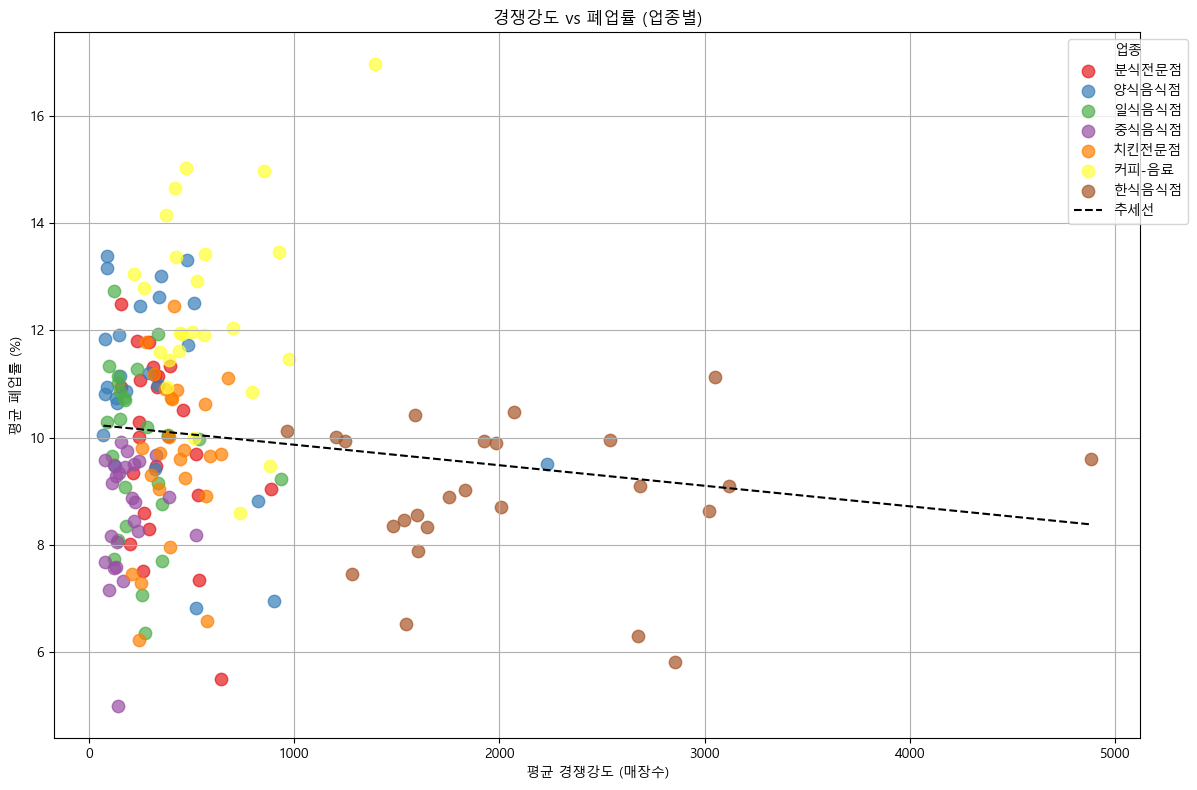

In [19]:
plt.figure(figsize=(12, 8))

for i, 업종 in enumerate(업종목록):
    temp = df_comp_scatter[df_comp_scatter['업종'] == 업종]
    plt.scatter(temp['평균_경쟁강도'],
                temp['평균_폐업률'],
                s=80, color=colors[i], label=업종, alpha=0.7)

# 추세선 추가
import numpy as np
x = df_comp_scatter['평균_경쟁강도']
y = df_comp_scatter['평균_폐업률']
z = np.polyfit(x, y, 1)
p = np.poly1d(z)
plt.plot(sorted(x), p(sorted(x)), color='black', linestyle='--', label='추세선')

plt.title('경쟁강도 vs 폐업률 (업종별)')
plt.xlabel('평균 경쟁강도 (매장수)')
plt.ylabel('평균 폐업률 (%)')
plt.legend(title='업종', bbox_to_anchor=(1.05, 1))
plt.grid(True)
plt.tight_layout()
plt.show()